In [16]:
import pandas as pd
import numpy as np

meta_csv_path = 'B0531+21_59000_48386_channels_meta.csv'
meta = pd.read_csv(meta_csv_path)

def sample_per_class(df, label_col='label', n_per_class=10000, random_state=42):
    """
    Return DataFrame where for each class (including NaN)
    we randomly sample up to n_per_class rows.
    """
    parts = []

    # NaN as a separate class
    nan_mask = df[label_col].isna()
    df_nan = df[nan_mask]
    if len(df_nan) > 0:
        take = min(n_per_class, len(df_nan))
        parts.append(df_nan.sample(n=take, random_state=random_state))
    
    # non-NaN classes
    df_not_nan = df[~nan_mask]
    for lbl in df_not_nan[label_col].unique():
        sub = df_not_nan[df_not_nan[label_col] == lbl]
        take = min(n_per_class, len(sub))
        parts.append(sub.sample(n=take, random_state=random_state))

    balanced_df = pd.concat(parts).reset_index(drop=True)
    return balanced_df

N = 10000
meta_balanced = sample_per_class(meta, label_col='label', n_per_class=N, random_state=42)

print("Original size:", len(meta))
print("Balanced size:", len(meta_balanced))
print("\nBalanced label distribution:")
print(meta_balanced['label'].value_counts(dropna=False))


/tmp/ipykernel_159160/2105068430.py:5: DtypeWarning: Columns (21,22) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv(meta_csv_path)


Original size: 6823936
Balanced size: 30000

Balanced label distribution:
label
NaN           10000
NoneWNBRFI    10000
NBRFI         10000
Name: count, dtype: int64


In [28]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

LOG_SPREAD_THRESHOLD = 1e2  # если max / min > этого значения → лог-шкала

def scatter_hist_multiclass(df, x_col, y_col, label_col,
                            ax_scatter, ax_histx, ax_histy,
                            bins=40, show_legend=False,
                            log_threshold=LOG_SPREAD_THRESHOLD):
    """
    Draw scatter plot + marginal histograms for multiple classes.
    Automatically switches to log-scale on an axis if:
      - all finite values on that axis > 0
      - max / min > log_threshold

    df          : DataFrame with data
    x_col, y_col: feature names
    label_col   : label column (e.g. 'label')
    ax_scatter  : central scatter axis
    ax_histx    : top histogram axis (X)
    ax_histy    : right histogram axis (Y)
    bins        : number of bins for histograms
    show_legend : whether to show legend on this scatter
    log_threshold : threshold for max/min ratio to trigger log-scale
    """

    # Disable tick labels on hist axes
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    # --- decide about log-scale for X and Y ---
    def should_use_log(values, threshold):
        values = np.asarray(values, dtype=float)
        values = values[np.isfinite(values)]
        if values.size == 0:
            return False
        vmin = np.nanmin(values)
        vmax = np.nanmax(values)
        # log-scale only if all > 0 and spread is big enough
        if vmin <= 0:
            return False
        if vmax / vmin > threshold:
            return True
        return False

    use_log_x = should_use_log(df[x_col].values, log_threshold)
    use_log_y = should_use_log(df[y_col].values, log_threshold)

    unique_labels = df[label_col].unique()

    # Prepare colors from default color cycle
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    n_colors = len(colors)

    handles = []
    labels_seen = []

    for idx, label_value in enumerate(unique_labels):
        if pd.isna(label_value):
            sub = df[df[label_col].isna()]
            label_str = 'NaN'
        else:
            sub = df[df[label_col] == label_value]
            label_str = str(label_value)

        if len(sub) == 0:
            continue

        color = colors[idx % n_colors]

        # scatter
        h = ax_scatter.scatter(
            sub[x_col],
            sub[y_col],
            s=3,
            alpha=0.3,
            color=color,
            label=label_str,
        )

        # histograms (бинning остаётся линейным, просто оси могут стать логарифмическими)
        ax_histx.hist(
            sub[x_col],
            bins=bins,
            histtype='stepfilled',
            alpha=0.3,
            color=color,
        )
        ax_histy.hist(
            sub[y_col],
            bins=bins,
            histtype='stepfilled',
            alpha=0.3,
            orientation='horizontal',
            color=color,
        )

        handles.append(h)
        labels_seen.append(label_str)

    # labels & grids
    ax_scatter.set_xlabel(x_col)
    ax_scatter.set_ylabel(y_col)
    ax_scatter.grid(True, linestyle='--', alpha=0.3)
    ax_histx.grid(True, linestyle='--', alpha=0.3)
    ax_histy.grid(True, linestyle='--', alpha=0.3)

    # apply log-scale if needed
    if use_log_x:
        ax_scatter.set_xscale('log')
        ax_histx.set_xscale('log')

    if use_log_y:
        ax_scatter.set_yscale('log')
        ax_histy.set_yscale('log')

    if show_legend and handles:
        ax_scatter.legend(handles=handles, labels=labels_seen, fontsize=8)

/tmp/ipykernel_159160/3030822944.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


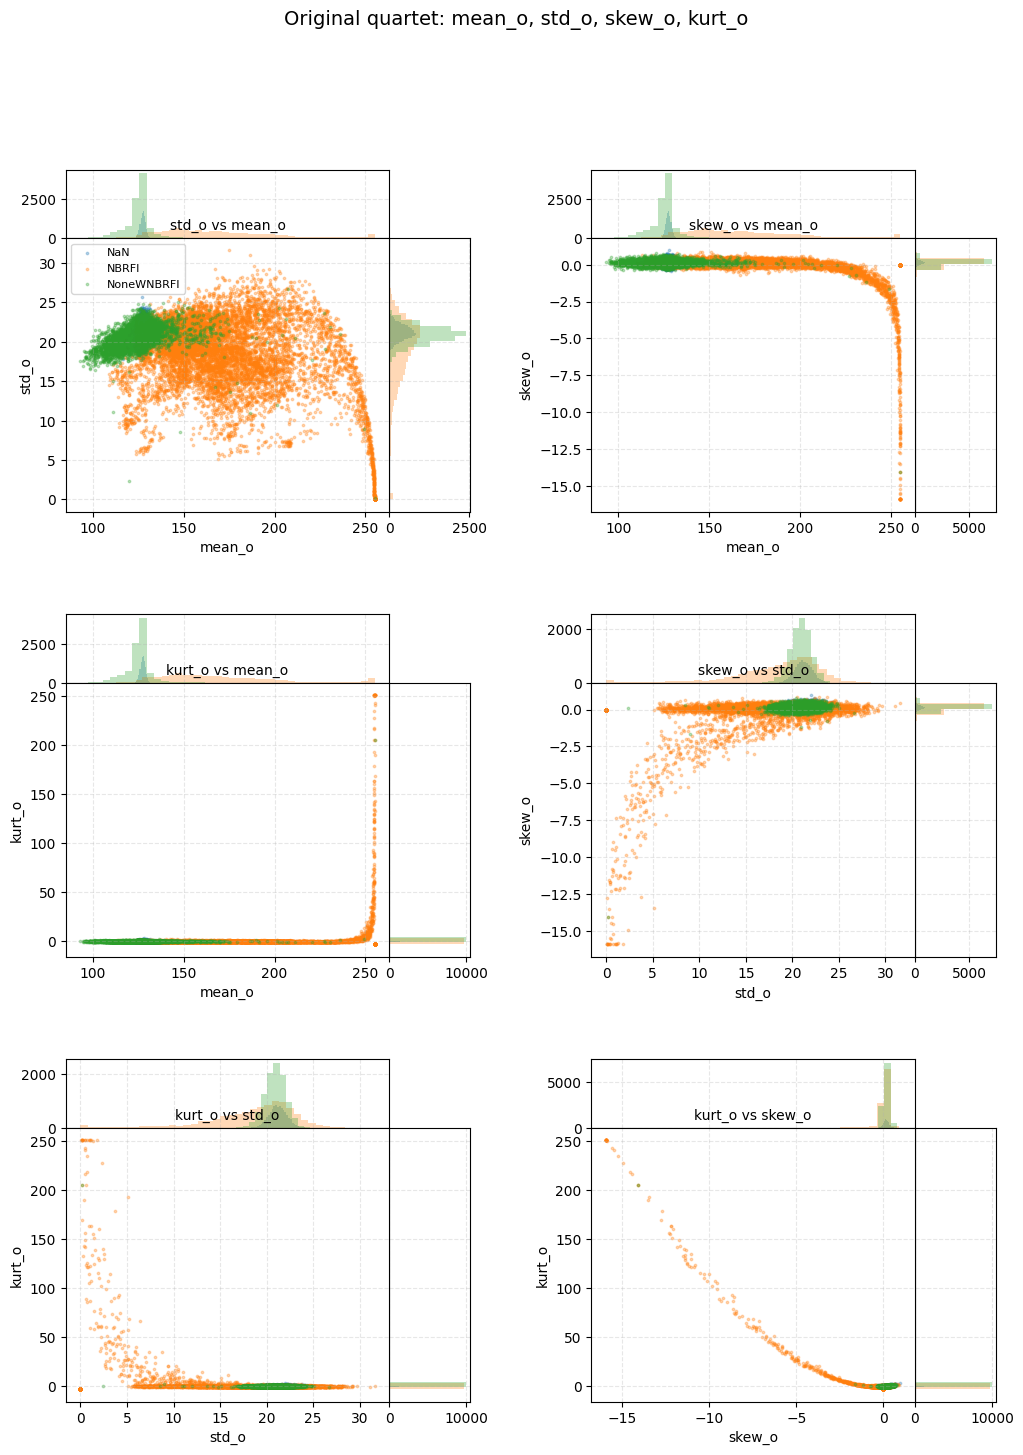

In [29]:
from matplotlib.gridspec import GridSpec

# choose quartet
features_original = ["mean_o", "std_o", "skew_o", "kurt_o"]

# to keep plots lighter, you can subsample again (optional)
df_plot = meta_balanced.sample(min(len(meta_balanced), 30000), random_state=42)

pairs = [
    (features_original[0], features_original[1]),
    (features_original[0], features_original[2]),
    (features_original[0], features_original[3]),
    (features_original[1], features_original[2]),
    (features_original[1], features_original[3]),
    (features_original[2], features_original[3]),
]

fig = plt.figure(figsize=(12, 16))
fig.suptitle("Original quartet: mean_o, std_o, skew_o, kurt_o", fontsize=14)

outer_gs = GridSpec(3, 2, figure=fig, wspace=0.3, hspace=0.3)

for idx, (x_col, y_col) in enumerate(pairs):
    row = idx // 2
    col = idx % 2

    inner_gs = outer_gs[row, col].subgridspec(
        2, 2,
        width_ratios=(4, 1),
        height_ratios=(1, 4),
        wspace=0.0,
        hspace=0.0
    )

    ax_histx = fig.add_subplot(inner_gs[0, 0])
    ax_histy = fig.add_subplot(inner_gs[1, 1])
    ax_scatter = fig.add_subplot(inner_gs[1, 0])
    ax_empty = fig.add_subplot(inner_gs[0, 1])
    ax_empty.axis('off')

    scatter_hist_multiclass(
        df=df_plot,
        x_col=x_col,
        y_col=y_col,
        label_col='label',
        ax_scatter=ax_scatter,
        ax_histx=ax_histx,
        ax_histy=ax_histy,
        bins=40,
        show_legend=(idx == 0)  # legend only on the first pair
    )

    ax_scatter.set_title(f"{y_col} vs {x_col}", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


/tmp/ipykernel_159160/3440918495.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


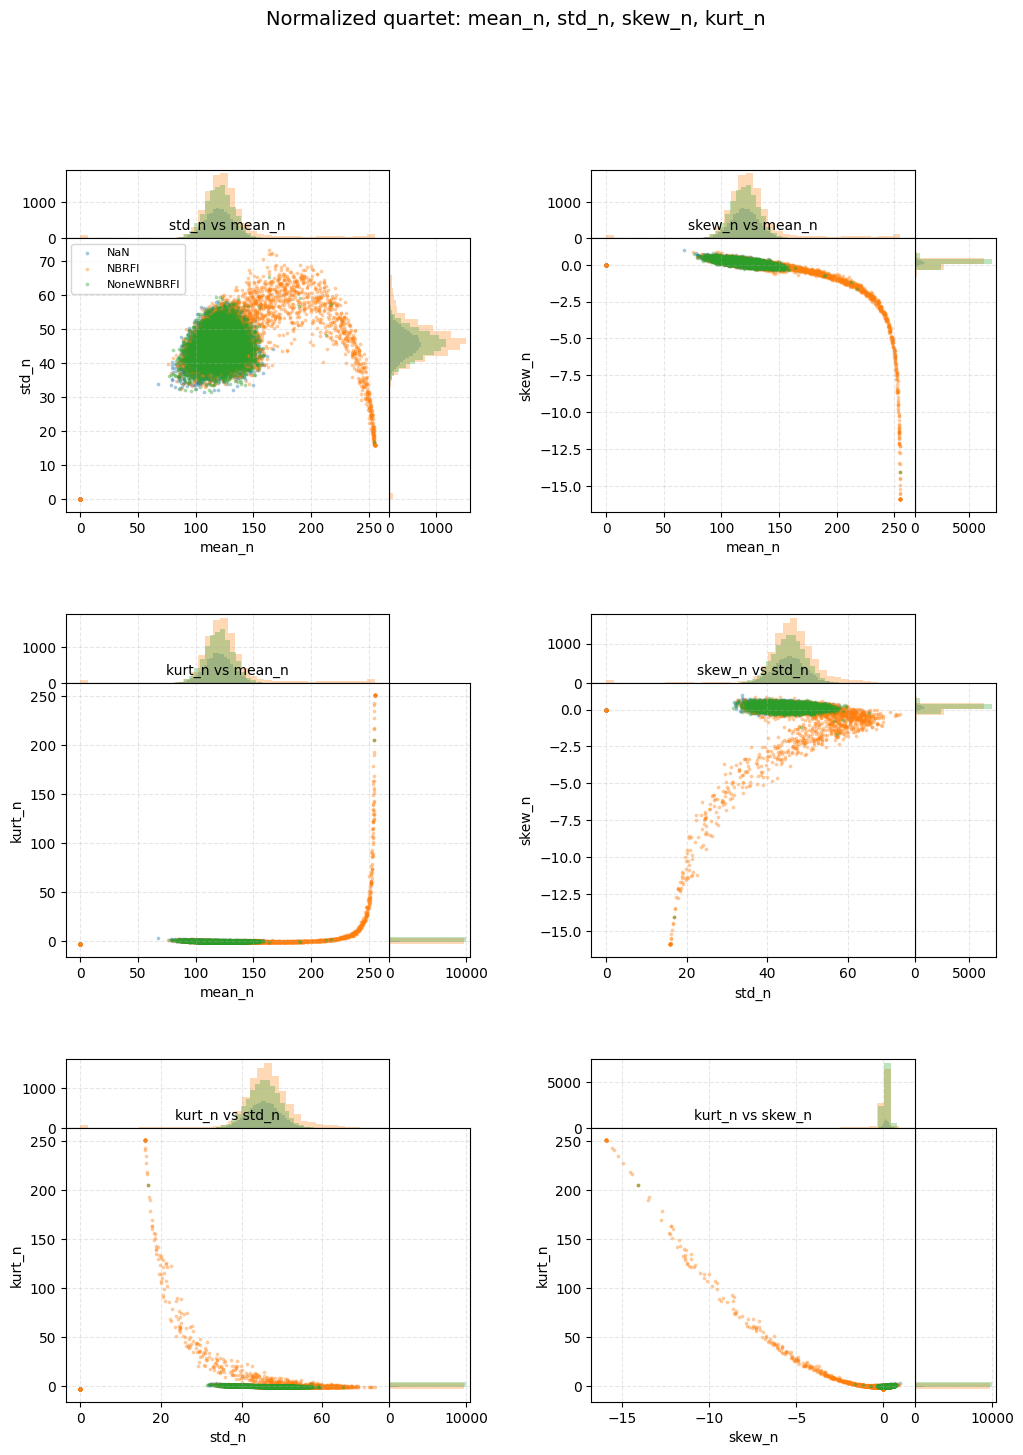

In [30]:
features_normalized = ["mean_n", "std_n", "skew_n", "kurt_n"]

df_plot = meta_balanced.sample(min(len(meta_balanced), 30000), random_state=42)

pairs = [
    (features_normalized[0], features_normalized[1]),
    (features_normalized[0], features_normalized[2]),
    (features_normalized[0], features_normalized[3]),
    (features_normalized[1], features_normalized[2]),
    (features_normalized[1], features_normalized[3]),
    (features_normalized[2], features_normalized[3]),
]

fig = plt.figure(figsize=(12, 16))
fig.suptitle("Normalized quartet: mean_n, std_n, skew_n, kurt_n", fontsize=14)

outer_gs = GridSpec(3, 2, figure=fig, wspace=0.3, hspace=0.3)

for idx, (x_col, y_col) in enumerate(pairs):
    row = idx // 2
    col = idx % 2

    inner_gs = outer_gs[row, col].subgridspec(
        2, 2,
        width_ratios=(4, 1),
        height_ratios=(1, 4),
        wspace=0.0,
        hspace=0.0
    )

    ax_histx = fig.add_subplot(inner_gs[0, 0])
    ax_histy = fig.add_subplot(inner_gs[1, 1])
    ax_scatter = fig.add_subplot(inner_gs[1, 0])
    ax_empty = fig.add_subplot(inner_gs[0, 1])
    ax_empty.axis('off')

    scatter_hist_multiclass(
        df=df_plot,
        x_col=x_col,
        y_col=y_col,
        label_col='label',
        ax_scatter=ax_scatter,
        ax_histx=ax_histx,
        ax_histy=ax_histy,
        bins=40,
        show_legend=(idx == 0)
    )

    ax_scatter.set_title(f"{y_col} vs {x_col}", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


/tmp/ipykernel_159160/2547428377.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


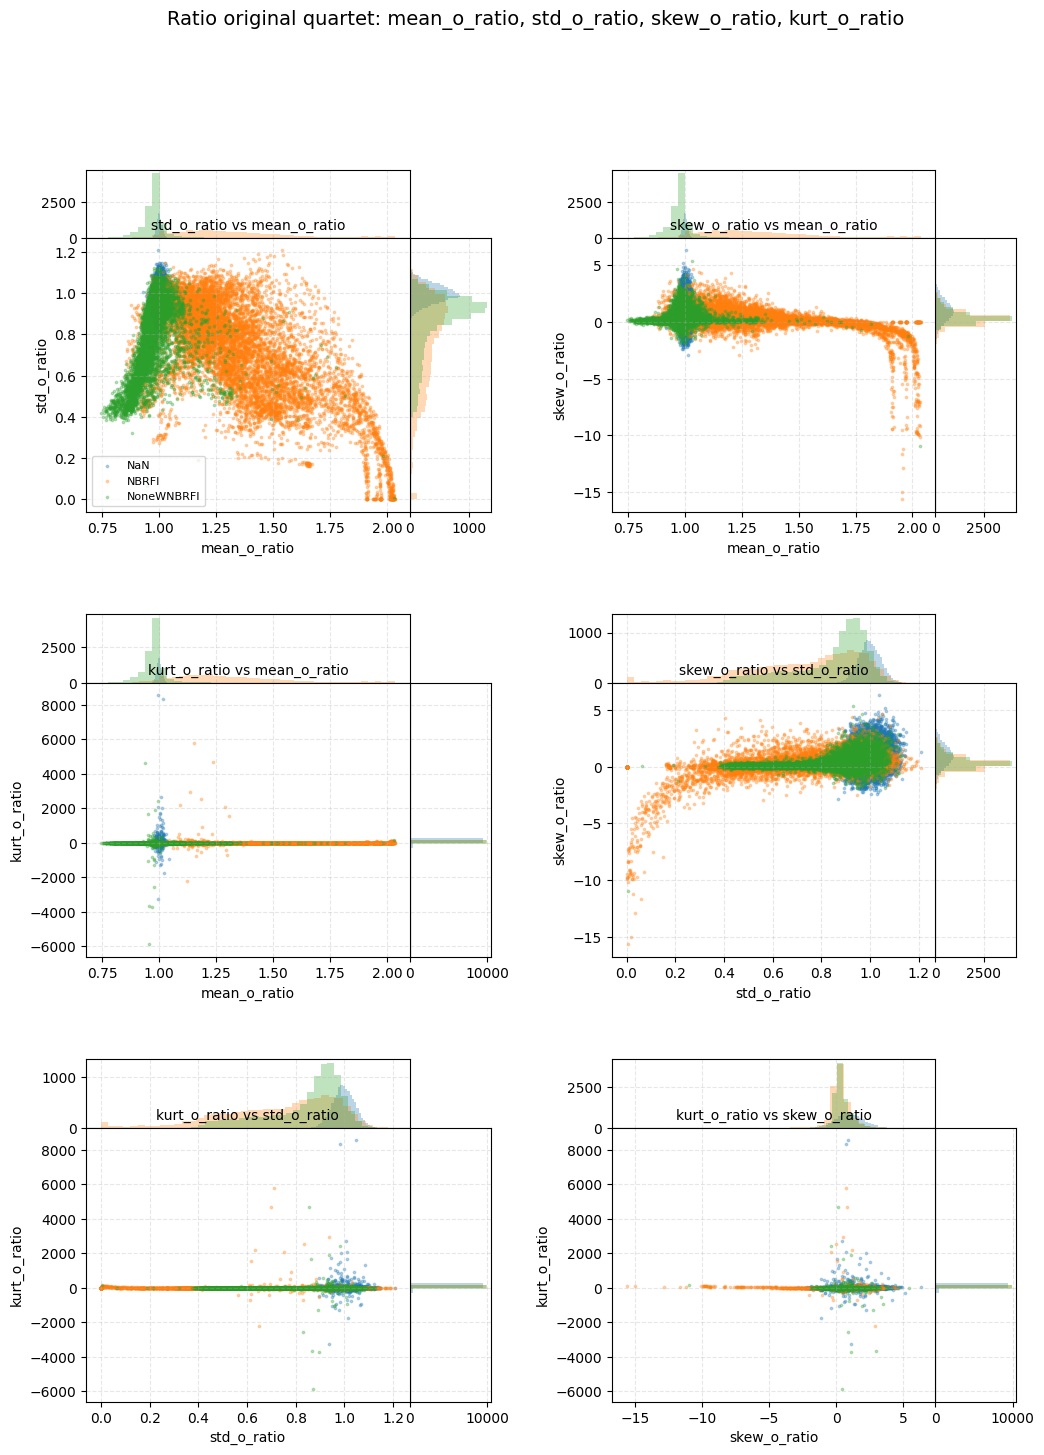

In [31]:
from matplotlib.gridspec import GridSpec

features_ratio_original = ["mean_o_ratio", "std_o_ratio", "skew_o_ratio", "kurt_o_ratio"]

# optional subsample to make plots lighter
df_plot = meta_balanced.sample(min(len(meta_balanced), 30000), random_state=42)

pairs = [
    (features_ratio_original[0], features_ratio_original[1]),
    (features_ratio_original[0], features_ratio_original[2]),
    (features_ratio_original[0], features_ratio_original[3]),
    (features_ratio_original[1], features_ratio_original[2]),
    (features_ratio_original[1], features_ratio_original[3]),
    (features_ratio_original[2], features_ratio_original[3]),
]

fig = plt.figure(figsize=(12, 16))
fig.suptitle("Ratio original quartet: mean_o_ratio, std_o_ratio, skew_o_ratio, kurt_o_ratio",
             fontsize=14)

outer_gs = GridSpec(3, 2, figure=fig, wspace=0.3, hspace=0.3)

for idx, (x_col, y_col) in enumerate(pairs):
    row = idx // 2
    col = idx % 2

    inner_gs = outer_gs[row, col].subgridspec(
        2, 2,
        width_ratios=(4, 1),
        height_ratios=(1, 4),
        wspace=0.0,
        hspace=0.0
    )

    ax_histx = fig.add_subplot(inner_gs[0, 0])
    ax_histy = fig.add_subplot(inner_gs[1, 1])
    ax_scatter = fig.add_subplot(inner_gs[1, 0])
    ax_empty = fig.add_subplot(inner_gs[0, 1])
    ax_empty.axis('off')

    scatter_hist_multiclass(
        df=df_plot,
        x_col=x_col,
        y_col=y_col,
        label_col='label',
        ax_scatter=ax_scatter,
        ax_histx=ax_histx,
        ax_histy=ax_histy,
        bins=40,
        show_legend=(idx == 0)  # legend only for the first pair
    )

    ax_scatter.set_title(f"{y_col} vs {x_col}", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


/tmp/ipykernel_159160/3696491362.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


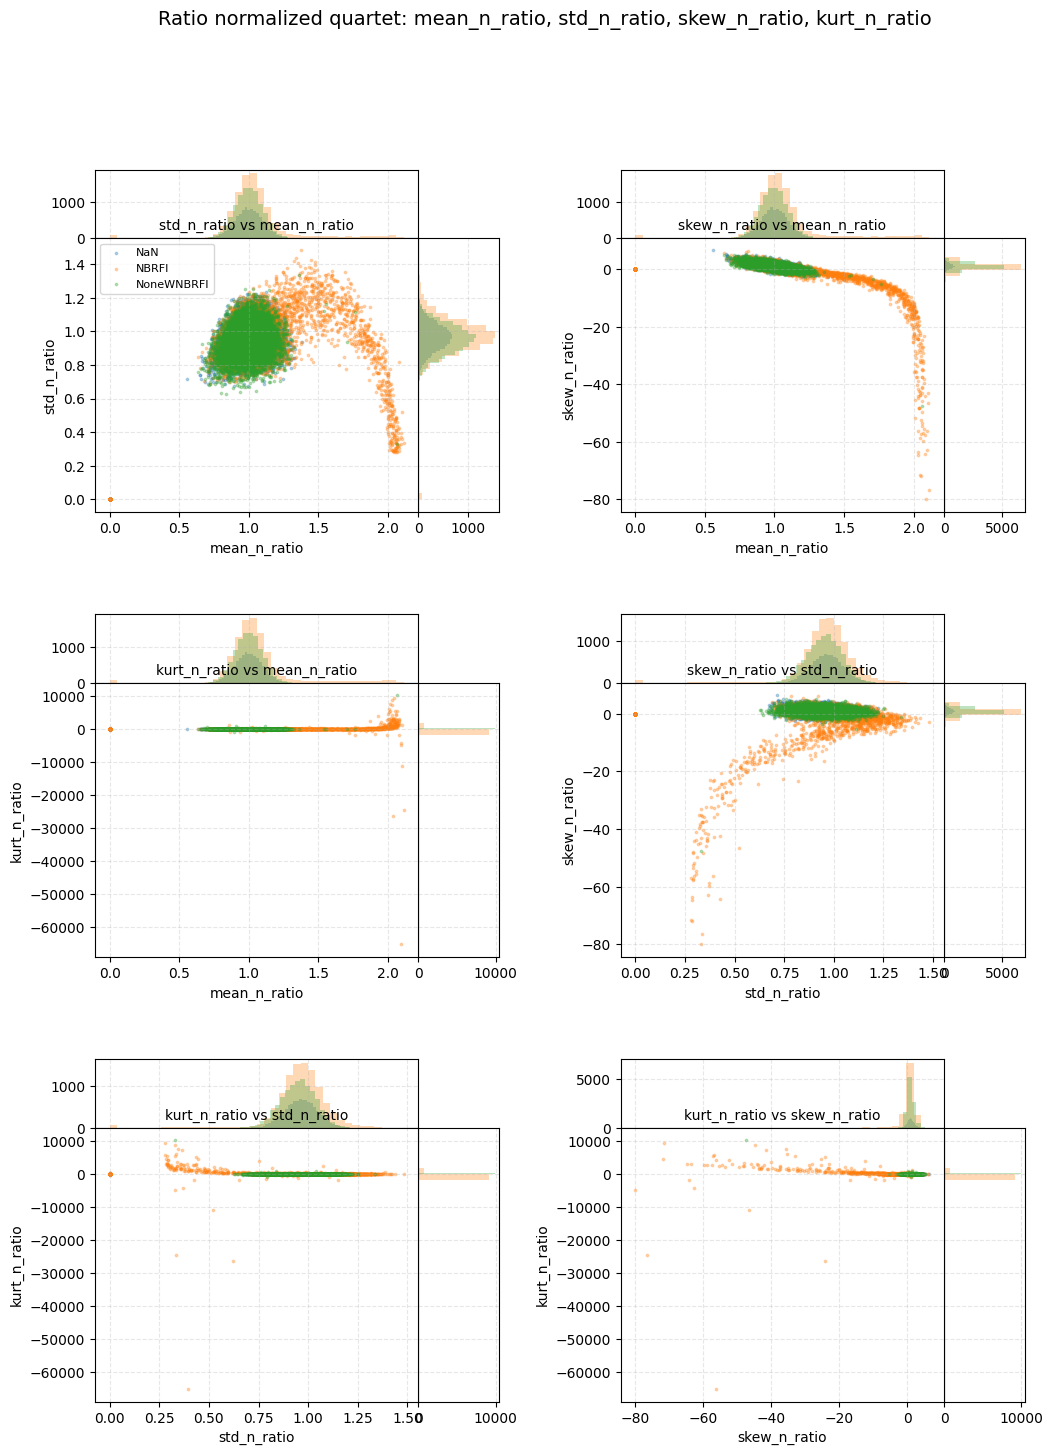

In [32]:
features_ratio_normalized = ["mean_n_ratio", "std_n_ratio", "skew_n_ratio", "kurt_n_ratio"]

# optional subsample
df_plot = meta_balanced.sample(min(len(meta_balanced), 30000), random_state=42)

pairs = [
    (features_ratio_normalized[0], features_ratio_normalized[1]),
    (features_ratio_normalized[0], features_ratio_normalized[2]),
    (features_ratio_normalized[0], features_ratio_normalized[3]),
    (features_ratio_normalized[1], features_ratio_normalized[2]),
    (features_ratio_normalized[1], features_ratio_normalized[3]),
    (features_ratio_normalized[2], features_ratio_normalized[3]),
]

fig = plt.figure(figsize=(12, 16))
fig.suptitle("Ratio normalized quartet: mean_n_ratio, std_n_ratio, skew_n_ratio, kurt_n_ratio",
             fontsize=14)

outer_gs = GridSpec(3, 2, figure=fig, wspace=0.3, hspace=0.3)

for idx, (x_col, y_col) in enumerate(pairs):
    row = idx // 2
    col = idx % 2

    inner_gs = outer_gs[row, col].subgridspec(
        2, 2,
        width_ratios=(4, 1),
        height_ratios=(1, 4),
        wspace=0.0,
        hspace=0.0
    )

    ax_histx = fig.add_subplot(inner_gs[0, 0])
    ax_histy = fig.add_subplot(inner_gs[1, 1])
    ax_scatter = fig.add_subplot(inner_gs[1, 0])
    ax_empty = fig.add_subplot(inner_gs[0, 1])
    ax_empty.axis('off')

    scatter_hist_multiclass(
        df=df_plot,
        x_col=x_col,
        y_col=y_col,
        label_col='label',
        ax_scatter=ax_scatter,
        ax_histx=ax_histx,
        ax_histy=ax_histy,
        bins=40,
        show_legend=(idx == 0)
    )

    ax_scatter.set_title(f"{y_col} vs {x_col}", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
